## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading data

In [2]:
df = pd.read_csv('../../data/raw/billings.csv')
df.head()

C:\Users\GauravGarg\AppData\Local\Temp\ipykernel_21312\936755889.py:1: DtypeWarning: Columns (0: Proforma_Auto_Renewal, 1: Proforma_World_Pay_Token, 2: Current_Anchor_List, 3: Last_Renewal, 4: Last_Band) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../data/raw/billings.csv')


,Co_Ref,Renewal_Month,Connection_Net,Connection_Qty,Discount_Amount,Sustainability_Score,Total_Renewal_Score_New,Starting_Connection_Net,Starting_Connection_Qty,Last_Years_Price,...,Connection_Group,Tenure_Group,#_of_Connection,Last_Renewal,Last_Band,Last_Total_Net_Paid,Last_Connections,Anchor_Group,Renewal_Year,DateTime_Out
0,VT6174,01-11-2024,NaN,NaN,NaN,8.0,42.5,NaN,NaN,799.0,...,1,3,1.0,01-11-2023,Band B,664.0,1.0,1,2024,01-11-2024
1,VD3828,01-08-2025,NaN,NaN,NaN,8.0,41.5,NaN,NaN,799.0,...,1,1,1.0,NaN,NaN,NaN,NaN,1,2025,01-08-2025
2,DV8120,01-03-2025,NaN,NaN,NaN,8.0,33.0,NaN,NaN,799.0,...,1,4+,1.0,01-03-2024,Band C1,749.0,1.0,1,2025,01-03-2025
3,EZ9894,01-06-2025,NaN,NaN,NaN,9.5,44.5,NaN,NaN,799.0,...,1,4+,1.0,01-06-2024,Band C1,749.0,1.0,1,2025,01-06-2025
4,FA8957,01-03-2025,NaN,NaN,NaN,9.5,42.5,NaN,NaN,799.0,...,1,3,1.0,01-03-2024,Band C1,749.0,1.0,1,2025,01-03-2025


## Initial Analysis

In [3]:
df.shape

(122082, 59)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 122082 entries, 0 to 122081
Data columns (total 59 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Co_Ref                      122082 non-null  str    
 1   Renewal_Month               122082 non-null  str    
 2   Connection_Net              8037 non-null    float64
 3   Connection_Qty              8037 non-null    float64
 4   Discount_Amount             13551 non-null   str    
 5   Sustainability_Score        122082 non-null  float64
 6   Total_Renewal_Score_New     122082 non-null  float64
 7   Starting_Connection_Net     8545 non-null    float64
 8   Starting_Connection_Qty     8545 non-null    float64
 9   Last_Years_Price            112992 non-null  float64
 10  Last_Years_Date_Paid        0 non-null       float64
 11  Auto_Renewal_Score          122082 non-null  int64  
 12  Status_Scores               122082 non-null  int64  
 13  Anchoring_Score          

In [5]:
df.describe()

,Connection_Net,Connection_Qty,Sustainability_Score,Total_Renewal_Score_New,Starting_Connection_Net,Starting_Connection_Qty,Last_Years_Price,Last_Years_Date_Paid,Auto_Renewal_Score,Status_Scores,...,Membership_Net,Package_Net,PQQNet,Total_Net_Paid,Amount,Total_Amount,#_of_Connection,Last_Total_Net_Paid,Last_Connections,Renewal_Year
count,8037.000000,8037.000000,122082.000000,122082.000000,8545.000000,8545.000000,112992.000000,0.0,122082.000000,122082.000000,...,122082.000000,122082.000000,122082.000000,101226.000000,122082.000000,122082.000000,121956.000000,73726.000000,73702.000000,122082.000000
mean,418.268259,5.799925,8.619530,41.983319,463.591223,6.419310,1063.854763,NaN,8.479506,7.187685,...,848.107740,60.233556,133.188996,1077.907507,1107.750864,1069.066063,3.198670,993.923497,3.547773,2024.300290
std,623.568386,7.608354,0.692765,4.291603,685.366345,8.401839,694.584676,NaN,0.499582,3.263780,...,533.440504,67.069747,48.608783,651.303068,689.139920,675.506405,6.548384,518.252054,6.951354,1.029394
min,55.000000,1.000000,8.000000,30.500000,55.000000,1.000000,0.000000,NaN,8.000000,0.000000,...,0.000000,0.000000,-529.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2023.000000
25%,99.000000,1.000000,8.000000,41.500000,110.000000,2.000000,664.000000,NaN,8.000000,7.000000,...,500.000000,0.000000,99.000000,684.000000,699.000000,684.000000,1.000000,684.000000,1.000000,2023.000000
50%,220.000000,3.000000,8.000000,43.500000,225.000000,3.000000,919.000000,NaN,8.000000,9.000000,...,674.000000,0.000000,135.000000,924.000000,934.000000,919.000000,1.000000,869.000000,2.000000,2024.000000
75%,474.000000,7.000000,9.500000,45.000000,495.000000,7.000000,1264.000000,NaN,9.000000,9.000000,...,1014.000000,120.000000,135.000000,1269.000000,1274.000000,1239.000000,3.000000,1149.000000,4.000000,2025.000000
max,4752.000000,48.000000,9.500000,46.500000,4752.000000,48.000000,18326.000000,NaN,9.000000,9.000000,...,13245.000000,225.000000,1930.000000,18326.000000,19927.000000,18326.000000,197.000000,12616.000000,197.000000,2050.000000


## Converting column names to snakecase

In [6]:
import sys
import os
sys.path.append(os.path.abspath('../..'))

In [7]:
from src import utils
df = utils.convert_columns_to_snake_case(df)

## Distribution of target variable

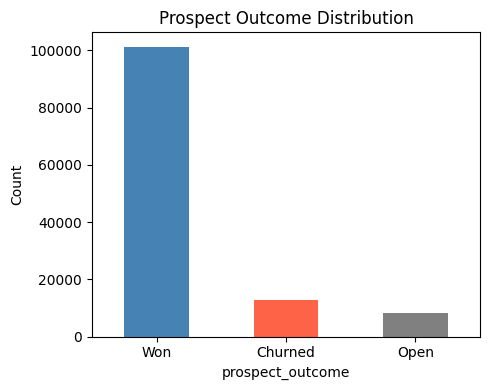

In [8]:
plt.figure(figsize=(5, 4))
df['prospect_outcome'].value_counts().plot(kind='bar', color=['steelblue','tomato','gray'])
plt.title('Prospect Outcome Distribution')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Checking duplicate record

In [9]:
df.duplicated(subset=['co_ref', 'renewal_year']).sum()

np.int64(0)

## Checking data types

In [10]:
df.dtypes

co_ref                            str
renewal_month                     str
connection_net                float64
connection_qty                float64
discount_amount                   str
sustainability_score          float64
total_renewal_score_new       float64
starting_connection_net       float64
starting_connection_qty       float64
last_years_price              float64
last_years_date_paid          float64
auto_renewal_score              int64
status_scores                   int64
anchoring_score               float64
tenure_scores                 float64
proforma_auto_renewal          object
proforma_world_pay_token       object
proforma_date                     str
current_anchorings              int64
current_anchor_list               str
payment_timeframe             float64
registration_date                 str
proforma_account_stage            str
proforma_audit_status             str
current_auto_renewal_flag         str
current_world_pay_token           str
renewal_scor

## Date columns are converted from string to datetime

In [11]:
df['registration_date'] = pd.to_datetime(df['registration_date'], dayfirst=True, errors='coerce')
df['proforma_date'] = pd.to_datetime(df['proforma_date'], dayfirst=True, errors='coerce')
df['prospect_renewal_date'] = pd.to_datetime(df['prospect_renewal_date'], dayfirst=True, errors='coerce')
df['last_renewal'] = pd.to_datetime(df['last_renewal'], dayfirst=True, errors='coerce')
df['renewal_month'] = pd.to_datetime(df['renewal_month'], dayfirst=True, errors='coerce')

## Checking null values

In [12]:
(df.isnull().mean() * 100).sort_values(ascending=False)

last_years_date_paid          100.000000
connection_qty                 93.416720
connection_net                 93.416720
starting_connection_net        93.000606
starting_connection_qty        93.000606
discount_amount                88.900084
last_connections               39.629102
last_total_net_paid            39.609443
last_band                      39.572582
last_renewal                   39.556200
current_anchor_list            21.261939
payment_timeframe              17.083600
total_net_paid                 17.083600
proforma_auto_renewal          14.786783
proforma_world_pay_token       14.786783
proforma_account_stage          7.559673
proforma_audit_status           7.559673
last_years_price                7.445815
closed_date                     6.706967
tenure_years                    0.833866
tenure_group                    0.833866
registration_date               0.833866
proforma_date                   0.249013
renewal_score_at_release        0.103209
proforma_approve

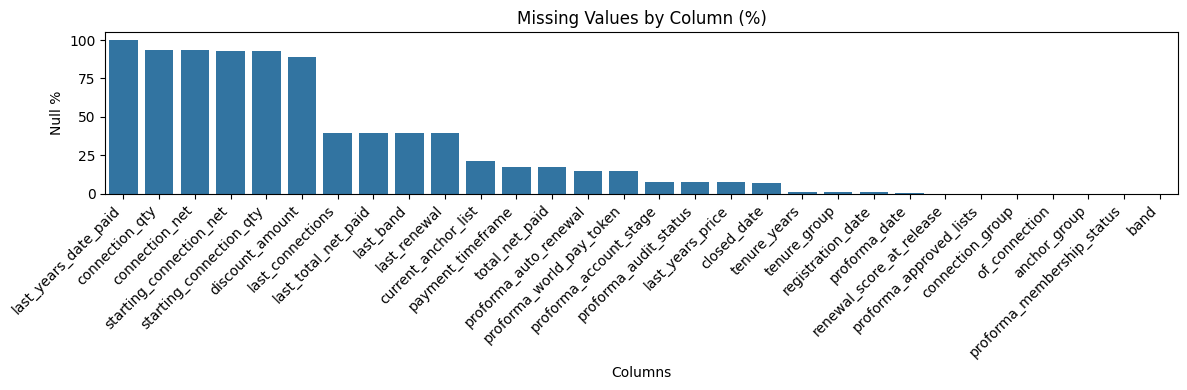

In [13]:
plt.figure(figsize=(12, 4))
null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]
sns.barplot(x=null_pct.index, y=null_pct.values)
plt.xticks(rotation=45, ha='right')
plt.title('Missing Values by Column (%)')
plt.xlabel('Columns')
plt.ylabel('Null %')
plt.tight_layout()
plt.show()

## Dropping fully null column

In [14]:
df.drop(columns=['last_years_date_paid'], inplace=True)

## Dropping >90% Null Columns

In [15]:
df.drop(columns=['connection_net','connection_qty','starting_connection_net','starting_connection_qty'], inplace=True)

## Removal of Leakage Columns

Columns `Closed_Date`, `Prospect_Status`, `Total_Net_Paid`, and `Gross` are removed as they contain post-outcome information.

In [16]:
df.drop(columns=[
    'closed_date',
    'prospect_status',
    'total_net_paid',
    'gross'
], inplace=True)

## Removal of free text column

`current_anchor_list` should be dropped because it is a free text column. Machine learning models cannot read text like this directly.

In [17]:
df.drop(columns=['current_anchor_list'], inplace=True)

## Detecting duplicate columns

In [18]:
duplicates = []
cols = df.columns.tolist()

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        c1, c2 = cols[i], cols[j]
        if df[c1].astype(str).equals(df[c2].astype(str)):
            duplicates.append((c1, c2))

for c1, c2 in duplicates:
    print(f"{c1}  ==  {c2}")

proforma_approved_lists  ==  of_connection
starting_net  ==  amount
connection_group  ==  anchor_group


## Fixing of duplicate columns

In [19]:
df.drop(columns=[
    'datetime_out',     # duplicate of Renewal_Month
    'of_connection',     # duplicate of Proforma_Approved_Lists
    'amount',           # duplicate of Starting_Net
    'connection_group',    # duplicate of Anchor_Group
], inplace=True)

## Removal of invalid pricing records

Records with `starting_net` less than or equal to zero are removed as they represent invalid or non-revenue cases.


In [20]:
df = df[df['starting_net'] > 0]

## Handling missing values

In [21]:
# Create a flag to identify first year customers
# If last_renewal is null then first year(1), else returning (0)
df['is_first_year'] = df['last_renewal'].isnull().astype(int)

# Fill missing previous payment with current price
# Assumes first year customers paid similar to current starting_net
df['last_total_net_paid'] =df['last_total_net_paid'].fillna(df['starting_net'])

# Fill missing previous connections with 0
# First year customers had no prior connections
df['last_connections'] = df['last_connections'].fillna(0)

# Fill missing previous band with current band
# Assumes no change in band for first year customers
df['last_band']=df['last_band'].fillna(df['band'])

# Fill missing previous renewal date with current renewal date
# Avoids issues in time based calculations for first year customers
df['last_renewal'] = df['last_renewal'].fillna(df['prospect_renewal_date'])

In [22]:
# Null means no discount was given
df['has_discount'] = df['discount_amount'].notna().astype(int)

# Parse the % string to float for the rows that have it
df['discount_pct'] = (
    df['discount_amount']
    .str.replace('%', '', regex=False)
    .astype(float) / 100
)
df['discount_pct'] = df['discount_pct'].fillna(0)

df.drop(columns=['discount_amount'], inplace=True)

In [23]:
df['payment_timeframe']= df['payment_timeframe'].fillna(0) # 0 = not yet paid

In [24]:
# Fill missing values using current status

df['proforma_auto_renewal'] = df['proforma_auto_renewal'].fillna(
    df['current_auto_renewal_flag'].map({'y': True, 'n': False})
)
df['proforma_world_pay_token'] = df['proforma_world_pay_token'].fillna(
    df['current_world_pay_token'].map({'y': True, 'n': False})
)

In [25]:
# Fill missing account stage and audit status with 'Unknown'

df['proforma_account_stage'] = df['proforma_account_stage'].fillna('Unknown')
df['proforma_audit_status'] = df['proforma_audit_status'].fillna('Unknown')

In [26]:
# Replace 0 with NaN first 
df['last_years_price'] = df['last_years_price'].replace(0, np.nan) 

# Fill nulls with starting_net (assume no price change) 
df['last_years_price'] = df['last_years_price'].fillna(df['starting_net'])

In [27]:
df.isnull().sum().sort_values(ascending=False)

registration_date             1015
tenure_group                  1015
tenure_years                  1015
proforma_date                  222
band                             7
last_band                        3
co_ref                           0
status_scores                    0
auto_renewal_score               0
anchoring_score                  0
tenure_scores                    0
total_renewal_score_new          0
last_years_price                 0
renewal_month                    0
sustainability_score             0
payment_timeframe                0
current_anchorings               0
proforma_auto_renewal            0
proforma_world_pay_token         0
current_world_pay_token          0
renewal_score_at_release         0
current_auto_renewal_flag        0
proforma_account_stage           0
proforma_approved_lists          0
prospect_renewal_date            0
starting_net                     0
starting_vat                     0
starting_gross                   0
starting_membership_

In [28]:
df['tenure_years'] = df['tenure_years'].fillna(df['tenure_years'].median())
df['tenure_group'] = df['tenure_group'].fillna(df['tenure_group'].mode()[0])
df['registration_date']=df['registration_date'].fillna(df['registration_date'].median())
df['proforma_date'] = df['proforma_date'].fillna(df['proforma_date'].median())
df['band'] = df['band'].fillna(df['band'].mode()[0])
df['last_band'] = df['last_band'].fillna(df['last_band'].mode()[0])

## Verifying after null handling

In [29]:
(df.isnull().sum()).sort_values(ascending=False)

co_ref                        0
renewal_month                 0
sustainability_score          0
total_renewal_score_new       0
last_years_price              0
auto_renewal_score            0
status_scores                 0
anchoring_score               0
tenure_scores                 0
proforma_auto_renewal         0
proforma_world_pay_token      0
proforma_date                 0
current_anchorings            0
payment_timeframe             0
registration_date             0
proforma_account_stage        0
proforma_audit_status         0
current_auto_renewal_flag     0
current_world_pay_token       0
renewal_score_at_release      0
proforma_membership_status    0
proforma_approved_lists       0
tenure_years                  0
band                          0
prospect_renewal_date         0
starting_net                  0
starting_vat                  0
starting_gross                0
starting_membership_net       0
starting_package_net          0
starting_pqq_net              0
membersh

## Numerical columns are converted to integer type

In [30]:
df['tenure_years'] = df['tenure_years'].astype(int)
df['last_connections'] = df['last_connections'].astype(int)
df['proforma_approved_lists'] = df['proforma_approved_lists'].astype(int)
df['payment_timeframe'] = df['payment_timeframe'].astype(int)

## Categorical features are converted category data type

In [31]:
cat_cols = ['band', 'last_band', 'tenure_group', 'anchor_group', 'payment_method', 'proforma_account_stage', 'proforma_audit_status', 'proforma_membership_status'] 
for col in cat_cols: 
    df[col] = df[col].astype('category')

## Standardization of categorical data

In [32]:
df['proforma_account_stage'] = df['proforma_account_stage'].str.strip().str.title()
(df['proforma_account_stage'].unique())

array(['Published', 'Membership Only', 'Renewal Process', 'Vetting',
       'Suspended', 'Retired', 'Unknown'], dtype=object)

In [33]:
df['payment_method'] = df['payment_method'].str.strip().str.title()
(df['payment_method'].unique())


array(['Card', 'Bacs', 'World Pay', 'Cheque', 'Unknown'], dtype=object)

In [34]:
df['band'] = df['band'].str.strip().str.title()
df['last_band'] = df['last_band'].str.strip().str.title()
(df['band'].unique())

array(['Band C1', 'Band D', 'Band C2', 'Band E', 'Band B', 'Group',
       'Band I', 'Band J', 'Band H', 'Band A', 'Band F2', 'Band F1',
       'Band G', 'Band F'], dtype=object)

In [35]:
df['tenure_group'] = df['tenure_group'].str.strip()
df['tenure_group'].unique()

array(['3', '1', '4+', '2'], dtype=object)

In [36]:
df['anchor_group'] = df['anchor_group'].str.strip()
df['anchor_group'].unique()

array(['1', '2', '3', '4 to 9', '10+', 'Independent'], dtype=object)

In [37]:
df['proforma_membership_status'] = df['proforma_membership_status'].str.strip().str.title()
(df['proforma_membership_status'].unique())

array(['Accredited', 'Member Only', 'In Progress', 'Non Member'],
      dtype=object)

## Final data shape

In [38]:
df.shape

(121953, 47)

## Exporting cleaned dataset

In [39]:
df.to_csv('../../data/interim/billings_cleaned.csv', index=False)

## Correlation Heatmap — Numeric Features

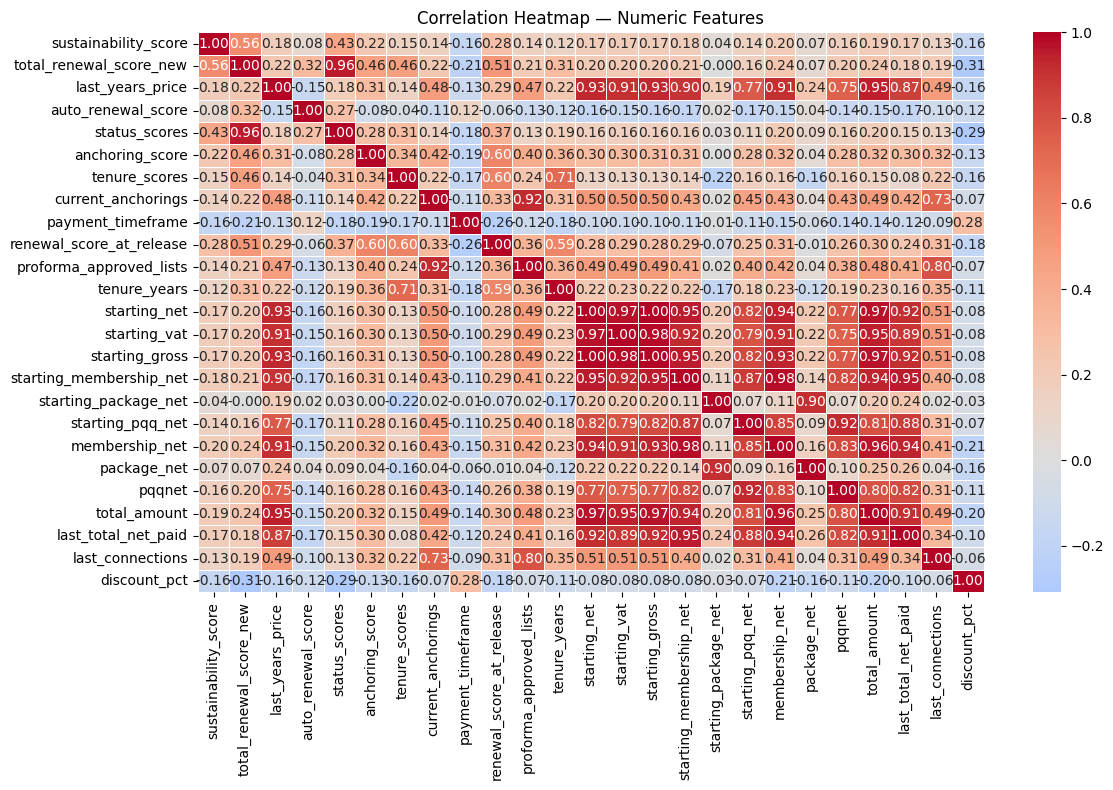

In [40]:
num_df = df.select_dtypes(include='number').drop(
    columns=['renewal_year', 'is_first_year', 'has_discount'], errors='ignore')

plt.figure(figsize=(12, 8))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

## Number of Renewals per Year

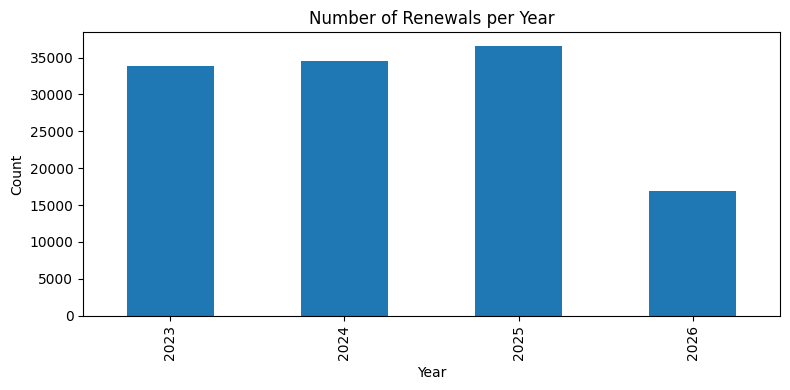

In [41]:
plt.figure(figsize=(8, 4))
df['renewal_year'].value_counts().sort_index().plot(
    kind='bar')
plt.title('Number of Renewals per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Starting Net Price Distribution by Band

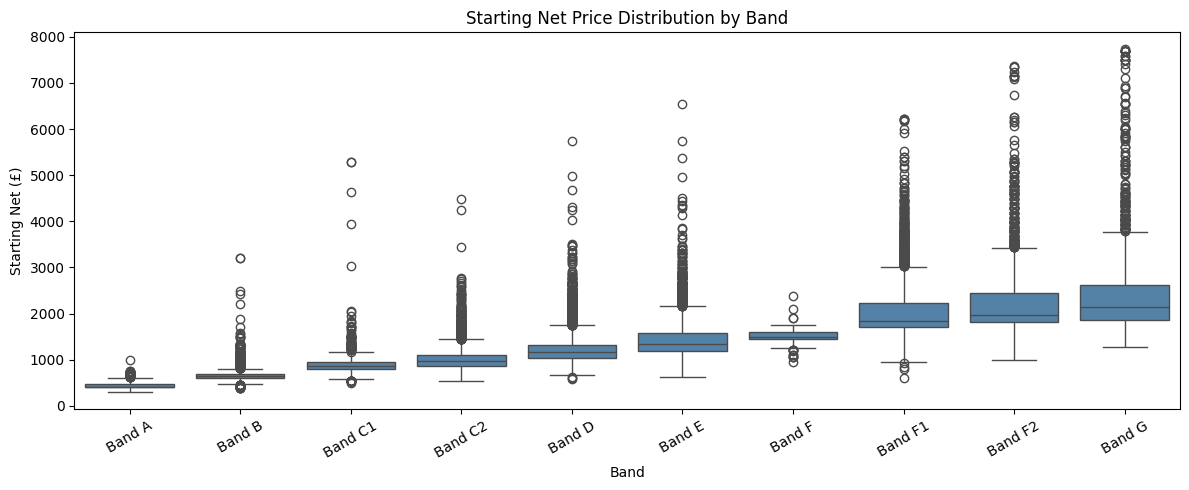

In [42]:
plt.figure(figsize=(12, 5))
band_order = ['Band A','Band B','Band C1','Band C2','Band D',
              'Band E','Band F','Band F1','Band F2','Band G']
sns.boxplot(data=df[df['band'].isin(band_order)],
            x='band', y='starting_net', order=band_order, color='steelblue')
plt.title('Starting Net Price Distribution by Band')
plt.xlabel('Band')
plt.ylabel('Starting Net (£)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Tenure Years & Tenure Group Distribution

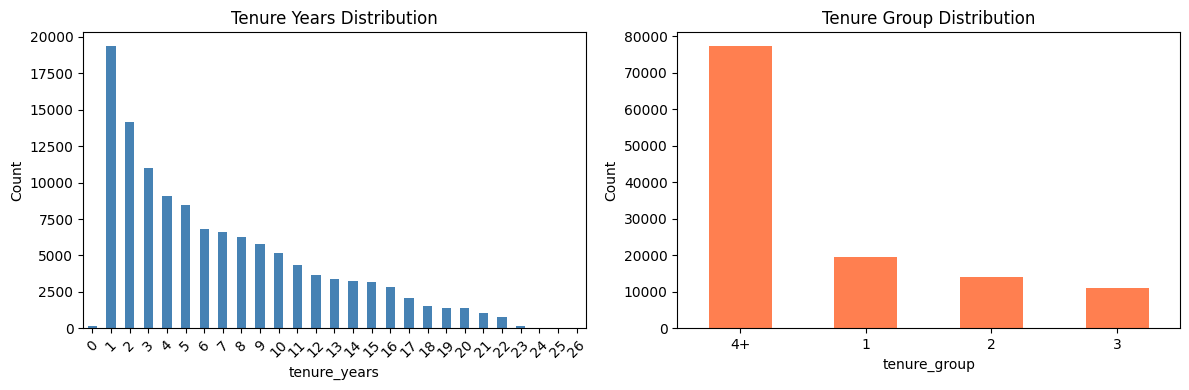

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Exact years
df['tenure_years'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Tenure Years Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Group
df['tenure_group'].value_counts().plot(
    kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Tenure Group Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()